In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
netflix = pd.read_csv('netflix_titles.csv')
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


#### 1. Understand The Data

In [3]:
print(netflix.info(),"\n")
print(netflix.isna().sum(),"\n\n")
print("Total Duplicates Records",netflix.duplicated().sum(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description   

In [4]:
# fill null value 
netflix['director'].fillna('Unknown',inplace=True)
netflix['cast'].fillna('Unknown',inplace=True)
netflix['country'].fillna('Unknown',inplace=True)
netflix['rating'].fillna(netflix['rating'].mode()[0],inplace=True)
netflix['duration'].fillna(netflix['duration'].mode()[0],inplace=True)

netflix['date_added'].fillna('Unknown',inplace=True)

#### 2. Exploratory Data Analysis

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64 check the type of the data


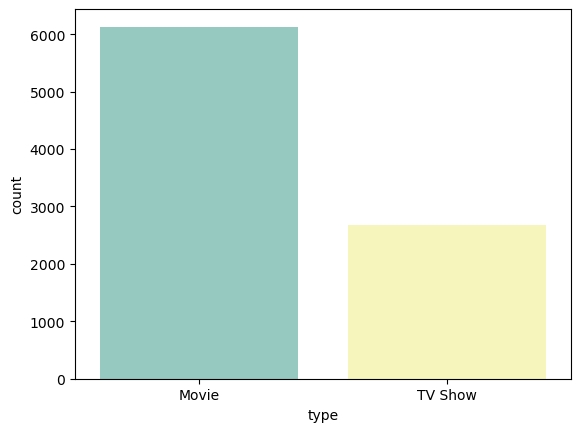

In [5]:
print(netflix['type'].value_counts(normalize=True)*100,"check the type of the data")
sns.countplot(x='type',data=netflix,palette='Set3')
plt.show()

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64 Check the country


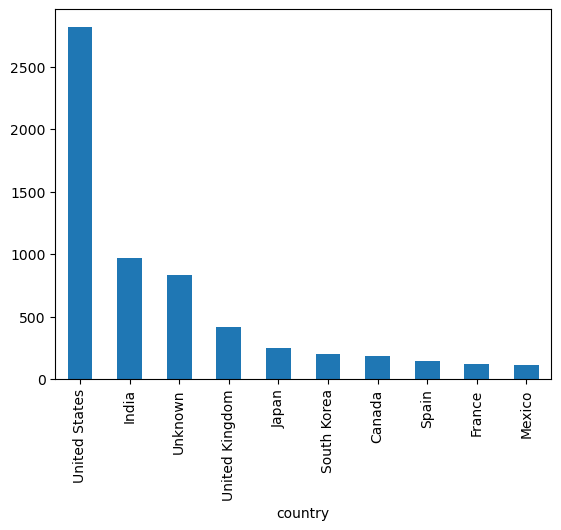

In [6]:
print(netflix['country'].value_counts().head(10),"Check the country")
netflix['country'].value_counts().head(10).plot(kind='bar')
plt.show()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64 check the year status of the release content


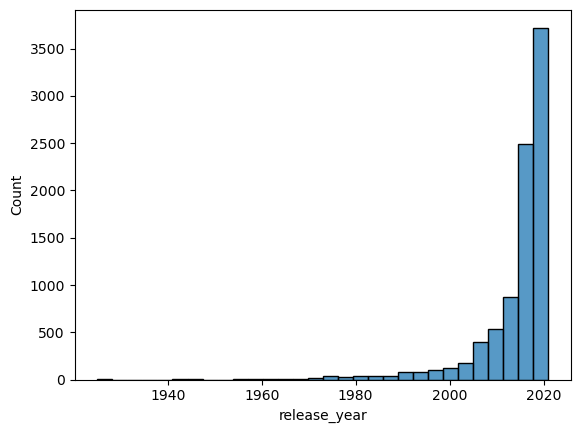

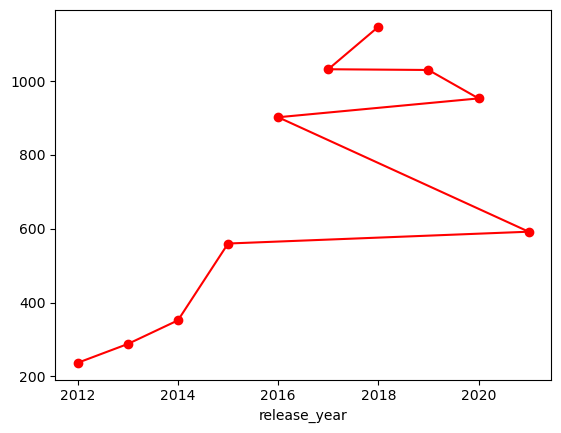

In [7]:
print(netflix['release_year'].value_counts().head(10),"check the year status of the release content")
sns.histplot(data=netflix,
            x='release_year',bins=30)
plt.show()


netflix['release_year'].value_counts().head(10).plot(kind='line',marker='o',
                                                    color='red')
plt.show()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


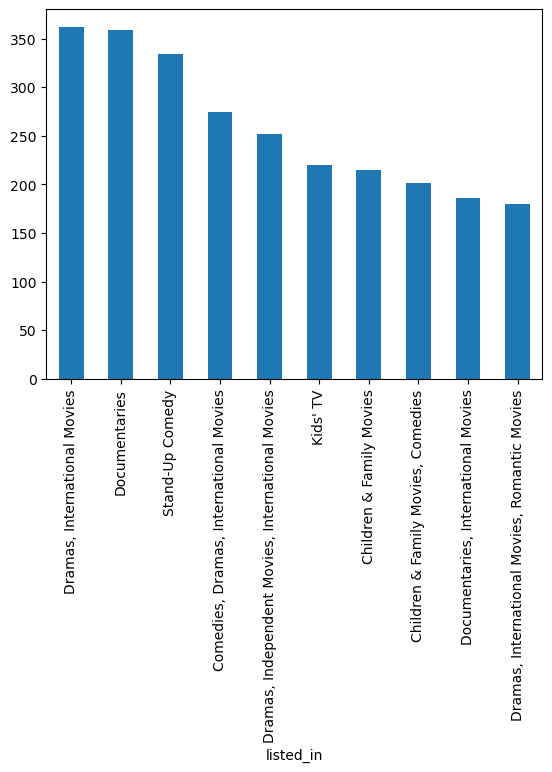

In [8]:
print(netflix['listed_in'].value_counts().head(10))
netflix['listed_in'].value_counts().head(10).plot(kind='bar')
plt.show()

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64


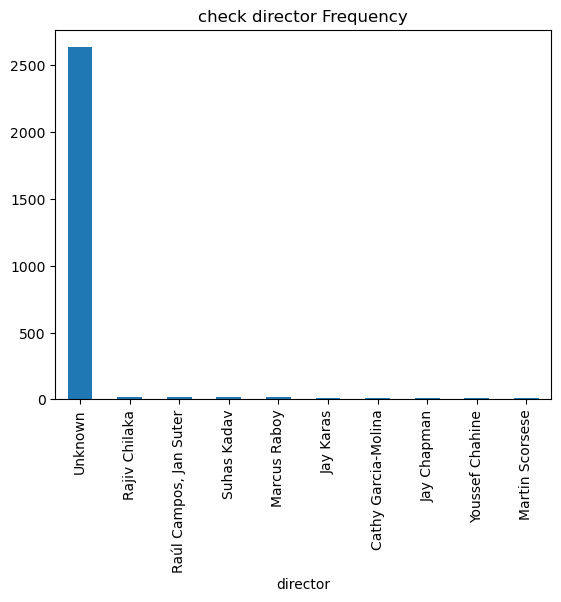

In [9]:
print(netflix['director'].value_counts().head(10))
netflix['director'].value_counts().head(10).plot(kind='bar')
plt.title("check director Frequency")
plt.show()

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


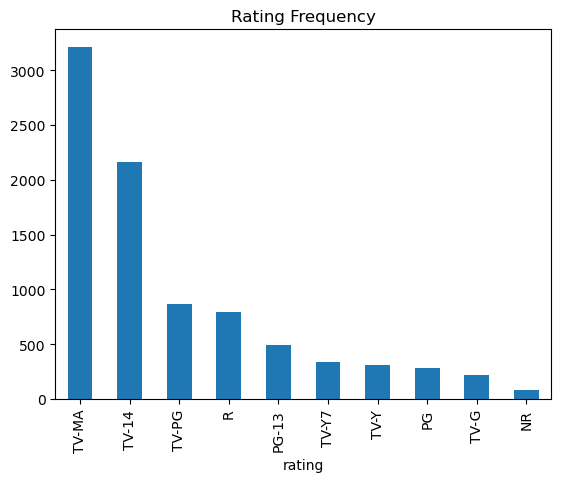

In [10]:
print(netflix['rating'].value_counts().head(10))
netflix['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Rating Frequency")
plt.show()

duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64


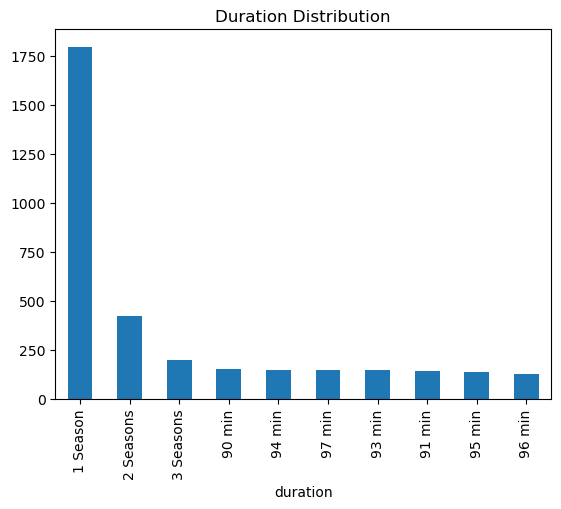

In [11]:
print(netflix['duration'].value_counts().head(10))
netflix['duration'].value_counts().head(10).plot(kind='bar')
plt.title("Duration Distribution")
plt.show()

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
Name: count, dtype: int64


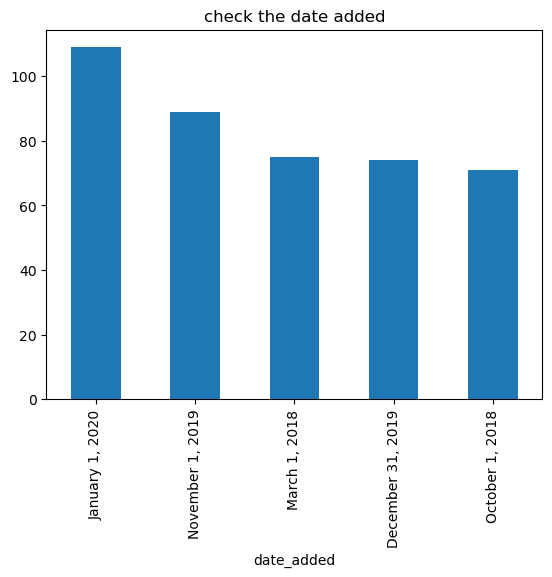

In [12]:
print(netflix['date_added'].value_counts().head())

netflix['date_added'].value_counts().head().plot(kind='bar')
plt.title("check the date added")
plt.show()

type
Movie      2058
TV Show     760
Name: count, dtype: int64


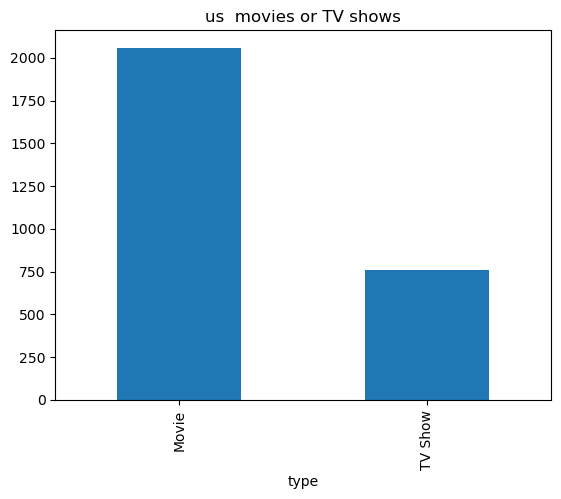

In [13]:
# check the how many number of movies and tv shows of the usa

usa_data = netflix[netflix['country']=='United States']
print(usa_data['type'].value_counts())
usa_data['type'].value_counts().plot(kind='bar')
plt.title("us  movies or TV shows")
plt.show()

duration
90 min     152
94 min     146
93 min     146
97 min     146
91 min     144
95 min     137
96 min     130
92 min     129
102 min    122
98 min     120
Name: count, dtype: int64


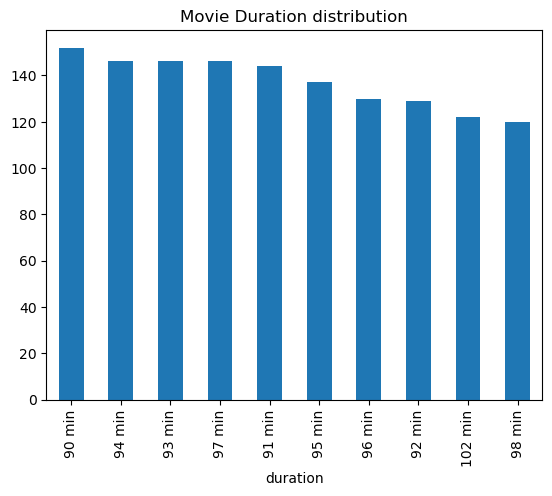

In [14]:
# find the common movies duration
movies = netflix[netflix['type']== 'Movie']
print(movies['duration'].value_counts().head(10))
movies['duration'].value_counts().head(10).plot(kind='bar')
plt.title('Movie Duration distribution')
plt.show()

type
Movie      893
TV Show     79
Name: count, dtype: int64


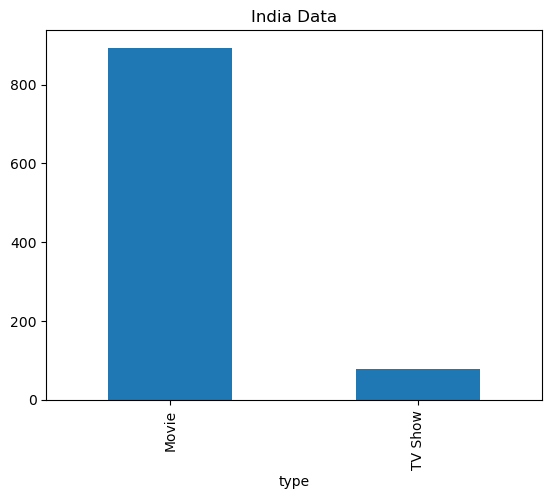

In [15]:
# only india have contains the how many movies or TV shows.
india_data=netflix[netflix['country']=='India']
print(india_data['type'].value_counts())

india_data['type'].value_counts().plot(kind='bar')
plt.title("India Data")
plt.show()

In [16]:
# after releasing 2015 how much movies are uploaded
after2015 = netflix[netflix['release_year']>2015]
after2015['type'].value_counts()

type
Movie      3619
TV Show    2037
Name: count, dtype: int64

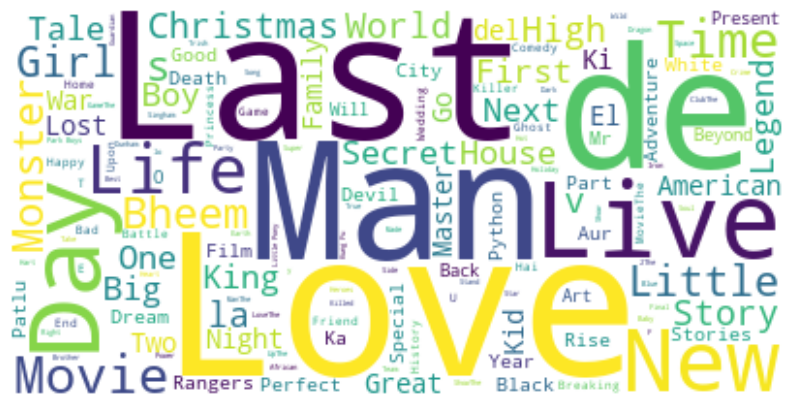

In [17]:
plt.figure(figsize=(10,8))
from wordcloud import WordCloud,STOPWORDS
text = "".join(netflix['title'])
stop = STOPWORDS

wc = WordCloud(background_color='white',
              stopwords=stop).generate(text)

plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.show()

### find the relationship

In [18]:

print(pd.crosstab(netflix['country'],netflix['type']).head(7))
print("\n\n")

print(pd.crosstab(netflix['release_year'],netflix['type']).head(7))
print("\n\n")

print(pd.crosstab(netflix['listed_in'],netflix['type']).head(7))

type                                                Movie  TV Show
country                                                           
, France, Algeria                                       1        0
, South Korea                                           0        1
Argentina                                              38       18
Argentina, Brazil, France, Poland, Germany, Den...      1        0
Argentina, Chile                                        2        0
Argentina, Chile, Peru                                  1        0
Argentina, France                                       1        0



type          Movie  TV Show
release_year                
1925              0        1
1942              2        0
1943              3        0
1944              3        0
1945              3        1
1946              1        1
1947              1        0



type                                                Movie  TV Show
listed_in                                                      

In [19]:
netflix.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


#### Insights Netflix Dataset 

Inside the Dataset. Data have huge of amount (Movies(70%) > TV Show (30%))

1. upload more content in the year 2018.
2. Us  uploade the more content.
3. US uploade the **31%** of content of the entire dataset and **TV shows** uploade the (760) and **Movies** uploade the (2058)
4. content listed on the drama, internation movies.
5. High Rating contains the **TV-MA**.(mature Audience 18+)
6. More Content have 1 session.
7. After 2016 netflix properly growing.
8. netflix more content add the jaunary.

## Using NLP
(Natural Language Process)

In [22]:
text_data = netflix['description']
text_data.head()

0    As her father nears the end of his life, filmm...
1    After crossing paths at a party, a Cape Town t...
2    To protect his family from a powerful drug lor...
3    Feuds, flirtations and toilet talk go down amo...
4    In a city of coaching centers known to train I...
Name: description, dtype: object

In [23]:
# apply the cleaning on the text data
import re

def text_clean(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]',' ',text)
    return text

netflix['clean_text'] = netflix['description'].apply(text_clean)  

In [24]:
# perform Tokenization 
netflix['token'] = netflix['clean_text'].apply(lambda x : x.split())

In [39]:
print(netflix['description'].iloc[0])
print(netflix['clean_text'].iloc[0])
print(netflix['token'].iloc[0])
print(netflix['processed_text'].iloc[0])

As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.
as her father nears the end of his life  filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable 
['father', 'near', 'end', 'life', 'filmmak', 'kirsten', 'johnson', 'stage', 'death', 'invent', 'comic', 'way', 'help', 'face', 'inevit']
father near end life filmmak kirsten johnson stage death invent comic way help face inevit


In [32]:
# remove the garbage words 
# stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
netflix['token'] = netflix['token'].apply(
    lambda words : [word for word in words if word not in stop_words])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gamin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [35]:
# stemming :

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
netflix['token'] = netflix['token'].apply(
    lambda words : [stemmer.stem(word) for word in words]
)

In [37]:
# vectorization :

netflix['processed_text'] = netflix['token'].apply(lambda x : " ".join(x))

In [48]:
# convert the number of the words

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features = 5000)

X = vectorizer.fit_transform(netflix['processed_text'])
y = netflix['type']

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = MultinomialNB()
model.fit(X_train,y_train)

accuracy = model.score(X_test,y_test)

print("Accuracy:",accuracy)

Accuracy: 0.7383654937570943


#### The Naive Bayes model achieved an accuracy of 73%, meaning the model correctly predicted the content type (Movie or TV Show) for 73% of the test samples.